In [1]:
import os
import pickle

import numpy as np
import pandas as pd

from typing import Optional
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, RegressorMixin

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

In [2]:
def prepare_X(X: pd.DataFrame, imputers: list[tuple], pipeline: ColumnTransformer, 
              colname_group: Optional[str]=None, flag_drop_col_group: bool=True, 
              colname_class: Optional[str]=None, flag_drop_col_class: bool=True) -> pd.DataFrame:
    """Impute and transform features for prediction.
    
    Args:
        X (pd.DataFrame): features to be prepared
        imputers (list[tuple]): list of (method, imputer, colnames) for imputing features
        pipeline (ColumnTransformer): transformer pipeline
        colname_group (str, optional): column name for group-based splitting. Defaults to None.
        colname_class (str, optional): column name for class-based splitting. Defaults to None
        flag_drop_col_group (bool): whether to drop group column. Defaults to True.
        flag_drop_col_class (bool): whether to drop class column. Defaults to True

    Returns:
        pd.DataFrame: prepared features
    """
    # Impute numerical and categorical features
    X_imputed = X.iloc[0:0].copy()
    for method, imputer, colnames in imputers:
        X_imputed[colnames] = imputer.transform(X[colnames])
    X_imputed.index = X.index
    
    # Transform features using pipeline
    X_transformed = pipeline.transform(X_imputed)
    X_transformed = pd.DataFrame(X_transformed, 
                                 columns=[name.split('__')[1] for name in pipeline.get_feature_names_out() if '__' in name], 
                                 index=X_imputed.index)
    X_transformed = X_transformed[X.columns.tolist()]
    
    # Drop the column for group-based data splittings
    if flag_drop_col_group and colname_group is not None:
        X_transformed = X_transformed.drop(colname_group, axis=1)
        
    # Drop the column for class-based data splitting
    if flag_drop_col_class and colname_class is not None:
        X_transformed = X_transformed.drop(colname_class, axis=1)
        
    # Ensure numeric data type
    X_transformed = X_transformed.apply(pd.to_numeric) # , errors='ignore')
    
    return X_transformed

In [3]:
class AvgRegressorCV(BaseEstimator, RegressorMixin):
    """Averaged regressor for cross-validated models."""
    def __init__(self, imputers_dict, pipeline_dict, regressor_dict):
        self.imputers_dict = imputers_dict
        self.pipeline_dict = pipeline_dict
        self.regressor_dict = regressor_dict

    def fit(self, X, y=None):
        # Regressors are already trained
        return self

    def predict(self, X):
        i = 0
        for cv_id, regressor in self.regressor_dict.items():
            imputers = self.imputers_dict[cv_id]
            pipeline = self.pipeline_dict[cv_id]
            X_prep = prepare_X(X, imputers, pipeline, colname_group='Group id', colname_class='Class id')
            pred = np.array(regressor.predict(X_prep)).reshape(-1, 1)
            pred_stack = pred if i == 0 else np.hstack((pred_stack, pred))
            i += 1
            
        return np.mean(pred_stack, axis=1)

# Data loading

In [4]:
reg_folder_dir = 'regs/'

# load feature imputers
dir = os.path.join(reg_folder_dir, 'X_imputers_dict.pkl')
with open(dir, 'rb') as f:
    X_imputers_dict = pickle.load(f)

# load feature transformers
dir = os.path.join(reg_folder_dir, 'X_transformers_dict.pkl')
with open(dir, 'rb') as f:
    X_transformers_dict = pickle.load(f)

# load regressors
dir = os.path.join(reg_folder_dir, 'regs_dict.pkl')
with open(dir, 'rb') as f:
    regs_dict = pickle.load(f)

# Create averaged cross-validated regressor
reg_avg = AvgRegressorCV(X_imputers_dict, X_transformers_dict, regs_dict)

In [5]:
data_folder_dir = 'data/'

# load augmented ground truth data
Xys_gt = pd.read_csv(f'{data_folder_dir}Xys_gt_augmented.csv')
# for consistency with the feature names in the model
Xys_gt.columns = Xys_gt.columns.str.replace('Solid', 'Binder', regex=True)

# Prediction

In [6]:
y_colname, y_colname_unit = 'Experimental CO2 uptake-U2', 'g/g solid'

y_gt = Xys_gt.loc[:, [y_colname]]
X_gt = Xys_gt.drop(y_colname, axis=1)

# make predictions
y_pred = reg_avg.predict(X_gt)
y_pred = pd.DataFrame(y_pred, index=y_gt.index, columns=[y_colname])

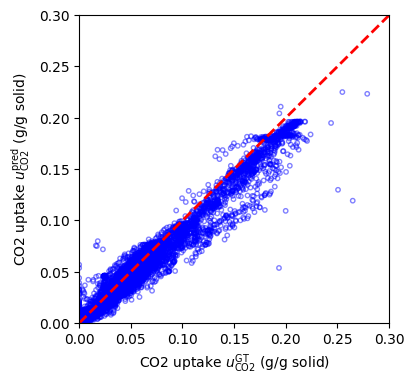

In [7]:
# predicted vs. ground truth scatter plot
plt.figure(figsize=(4, 4))

plt.scatter(y_gt[y_colname], y_pred[y_colname], 
            color='blue', marker='o',facecolor='none', s=10, alpha=0.5)

plt.plot([0,0.3], [0, 0.3], # reference line
         color='red', linestyle='--', linewidth=2)

plt.xlabel(f'CO2 uptake $u_{{\mathrm{{CO2}}}}^{{\mathrm{{GT}}}}$ ({y_colname_unit})')
plt.xlim(0, 0.3)
plt.ylabel(f'CO2 uptake $u_{{\mathrm{{CO2}}}}^{{\mathrm{{pred}}}}$ ({y_colname_unit})')
plt.ylim(0, 0.3)

plt.show()